# Neural Models
This notebook is solution for the lab `Neural Models.pdf`

### Task 1: Understand the problem before coding

Let the input space be:
X = { (x1, x2) | x1, x2 ∈ {0,1} }

and the output space be:
Y = {0, 1}

The dataset contains exactly four labelled examples, corresponding to the four corners of the unit square:
(0, 0), (0, 1), (1, 0), (1, 1)

Each point belongs to one of two classes. The task is to decide whether the class pattern can be separated by a single straight decision boundary.

A single straight line cannot separate the classes here because the class pattern is not linearly separable. In other words, there is no one line that puts all examples of one class on one side and all examples of the other class on the other side.

Prediction:
If we train only one affine transformation followed by a sigmoid, the model can only learn one linear boundary. Therefore, it will behave like a linear classifier and cannot represent this class pattern correctly.

Input space X:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Output labels y:
[0 1 1 0]


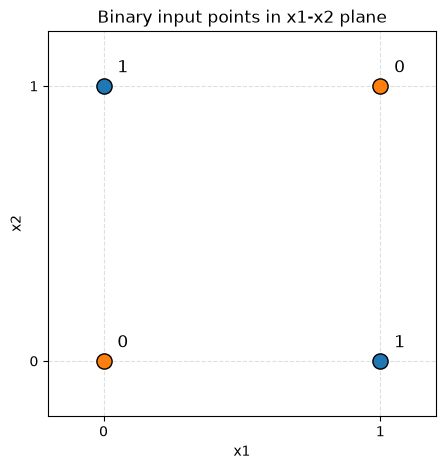

In [37]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

print("Input space X:")
print(X)
print("\nOutput labels y:")
print(y)

fig, ax = plt.subplots(figsize=(5, 5))
for i, (x1, x2) in enumerate(X):
    color = 'tab:blue' if y[i] == 1 else 'tab:orange'
    ax.scatter(x1, x2, c=color, s=120, edgecolor='black', zorder=3)
    ax.text(x1 + 0.05, x2 + 0.05, str(y[i]), fontsize=12)

ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.2, 1.2)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Binary input points in x1-x2 plane")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

### Task 2: Designing the network

We will design a minimal neural model on paper before asking any LLM for code.

Baseline architecture:
- Inputs: 2 features
- Hidden layer: 2 hidden units
- Output: 1 unit

Proposed model:
- Hidden activation: sigmoid or tanh
- Output activation: sigmoid
- Loss: binary cross-entropy
- Optimiser: gradient-based optimisation

This is a small network, but it is still expressive enough to test whether a nonlinear representation can solve the XOR-like classification problem.

1. Why is the hidden nonlinearity scientifically necessary here?

A hidden nonlinear activation is necessary because without it, the whole network collapses to a single affine transformation. That means the model can only represent one linear decision boundary, which is exactly the limitation we are trying to test. The XOR pattern is not linearly separable, so a purely linear model cannot represent it. The hidden nonlinearity gives the network a way to build a richer internal representation.

2. Why is sigmoid plus binary cross-entropy a sensible engineering pairing for the output?

The output is a yes/no decision, so a sigmoid is natural because it maps the final activation to a probability-like value between 0 and 1. Binary cross-entropy is then a suitable loss because it penalises incorrect probabilities in a way that is well matched to binary classification. This combination is standard and gives a clean gradient signal for learning.

3. What evidence counts as successful learning?

We need to define objective checks for training. At least three checks are useful:

- Final loss is sufficiently low and decreases over training iterations.
- The model predicts the correct class for all four training examples.
- The gradients are nonzero at the start and during training, showing the network is actually learning rather than stuck.
- Repeated runs behave consistently, meaning the training is stable and not just a lucky random outcome.
- A stronger practical check is that after training, the model outputs values near 0 or 1 for the four inputs, with the correct labels.

Checkpoint to record:
> Model specification: 2 inputs -> 2 hidden units -> 1 output, hidden activation = sigmoid/tanh, output activation = sigmoid, loss = binary cross-entropy, optimized by gradient descent. Validation criteria: final loss decreases, all four labels are predicted correctly, gradients are nonzero and training is stable across repeated runs.

### Task 3: Use an LLM to generate a first implementation

We use a minimal 2-2-1 neural network on the XOR dataset. The hidden layer uses a sigmoid activation, the output uses logits with BCEWithLogitsLoss, and training is done with full-batch gradient descent for a few thousand steps.

The forward pass is the computation:
- $h = \sigma(X W_1 + b_1)$
- $\text{logits} = h W_2 + b_2$
- $\mathcal{L} = \text{BCEWithLogitsLoss}(\text{logits}, y)$

Reverse-mode autodiff is invoked by calling loss.backward(), which computes gradients for all parameters. The optimiser then updates the weights with optimizer.step().

This implementation is the first engineering version of the design from Task 2. It is useful because it tests whether the network can learn the XOR function with a nonlinear hidden layer and proper binary classification loss.

Key checks before trusting the result:
- final loss decreases over training;
- all four predictions match the XOR labels;
- at least one gradient is nonzero after backward();
- repeated runs are stable under the same random seed.

In [38]:
import torch
import torch.nn as nn

# Reproducibility
torch.manual_seed(0)

# XOR dataset: four training examples
X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
], dtype=torch.float32)

y = torch.tensor([0.0, 1.0, 1.0, 0.0], dtype=torch.float32).view(-1, 1)

# 2 -> 2 -> 1 network
model = nn.Sequential(
    nn.Linear(2, 2),
    nn.Sigmoid(),
    nn.Linear(2, 1),
)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

for epoch in range(5000):
    optimizer.zero_grad()

    # Forward pass: X -> hidden -> logits
    logits = model(X)

    # Scalar loss: binary cross-entropy on logits
    loss = criterion(logits, y)

    # Reverse-mode autodiff
    loss.backward()

    # Optimiser updates parameters
    optimizer.step()

with torch.no_grad():
    probs = torch.sigmoid(model(X))
    labels = (probs >= 0.5).float()
    print(f"Final loss: {loss.item():.6f}")
    print("Probabilities:", probs.view(-1).tolist())
    print("Thresholded labels:", labels.view(-1).tolist())
    print("Target labels:", y.view(-1).tolist())
    print("Gradient for first layer weight:")
    print(model[0].weight.grad)

Final loss: 0.038970
Probabilities: [0.043116092681884766, 0.9676053524017334, 0.9676045775413513, 0.04475623741745949]
Thresholded labels: [0.0, 1.0, 1.0, 0.0]
Target labels: [0.0, 1.0, 1.0, 0.0]
Gradient for first layer weight:
tensor([[-0.0020, -0.0020],
        [ 0.0012,  0.0012]])


### Task 4: Execute, test, and diagnose the generated code

Part A – Basic learning check
The experiment should be evaluated by comparing the initial loss and the final loss. The crucial evidence is that the final probabilities for the four XOR inputs are close to 0 or 1 and that thresholding them yields the correct labels. If the labels are not all correct, the engineering change should be limited to justified settings such as learning rate, number of steps, random seed, or optimiser, while keeping the same scientific task and architecture.

Part B – Backpropagation check
After a forward pass and a call to backward(), the tensor stored in parameter.grad is the gradient of the scalar loss with respect to that parameter matrix. For the first-layer weights, this is $\frac{\partial \mathcal{L}}{\partial W^{(1)}}$. If the loss is averaged over the four examples, then the reported gradient is the mean of the example-wise gradients, because each example contributes its own gradient and the average is taken before the update.

Part C – Symmetry experiment
When all weights are initialised to zero, the two hidden units start identical and receive the same inputs, so they compute the same hidden activations and receive the same gradients. The result is that the two rows of the hidden-layer weight matrix stay identical during training. This is a symmetry-breaking failure: without asymmetry in the initial parameters, the hidden units cannot specialise to different roles.

Part D – Activation experiment
Training with sigmoid, tanh, and ReLU changes the optimisation dynamics because each activation has a different gradient flow and a different nonlinear geometry. The relevant evidence is the final loss, whether all four XOR labels are classified correctly, and the Euclidean norm of the first-layer gradient at an early training step. The goal is not to declare one activation universally best from four points, but to explain how the observed differences arise from the activation-specific signal propagation and optimisation behaviour.

In [39]:
import torch
import torch.nn as nn

X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
], dtype=torch.float32)

y = torch.tensor([0.0, 1.0, 1.0, 0.0], dtype=torch.float32).view(-1, 1)


def build_model(hidden_activation: str, seed: int = 0):
    torch.manual_seed(seed)
    activations = {
        'sigmoid': nn.Sigmoid(),
        'tanh': nn.Tanh(),
        'relu': nn.ReLU(),
    }
    if hidden_activation not in activations:
        raise ValueError(f'Unknown activation: {hidden_activation}')

    return nn.Sequential(
        nn.Linear(2, 2),
        activations[hidden_activation],
        nn.Linear(2, 1),
    )


def train_once(hidden_activation='sigmoid', seed=0, lr=0.5, steps=5000):
    torch.manual_seed(seed)

    X_bin = torch.tensor([
        [0.0, 0.0],
        [0.0, 1.0],
        [1.0, 0.0],
        [1.0, 1.0],
    ], dtype=torch.float32)

    y_bin = torch.tensor([0.0, 1.0, 1.0, 0.0], dtype=torch.float32).view(-1, 1)

    model = build_model(hidden_activation, seed)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    with torch.no_grad():
        initial_logits = model(X_bin)
        initial_loss = criterion(initial_logits, y_bin).item()

    for _ in range(steps):
        optimizer.zero_grad()
        logits = model(X_bin)
        loss = criterion(logits, y_bin)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        logits = model(X_bin)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        final_loss = criterion(logits, y_bin).item()
        grad_norm = model[0].weight.grad.norm().item()
        correct = torch.all(preds.view(-1) == y_bin.view(-1))

    return {
        'initial_loss': initial_loss,
        'final_loss': final_loss,
        'probs': probs.view(-1).tolist(),
        'preds': preds.view(-1).tolist(),
        'labels': y_bin.view(-1).tolist(),
        'correct': correct,
        'grad_norm': grad_norm,
        'W1_grad': model[0].weight.grad.clone(),
    }

# Part A: basic learning check
result = train_once('sigmoid', seed=0, lr=0.5, steps=5000)
print('Part A: Basic learning check')
print('Initial loss:', result['initial_loss'])
print('Final loss:', result['final_loss'])
print('Final probabilities:', result['probs'])
print('Thresholded predictions:', result['preds'])
print('Target labels:', result['labels'])
print('All four labels correct?:', result['correct'])

# Part B: backpropagation check
print('\nPart B: Backpropagation check')
print('Gradient of first-layer weights W1:')
print(result['W1_grad'])
print('Interpretation: parameter.grad stores dL/dW^(1), the derivative of the scalar loss with respect to the first-layer weight matrix.')
print('If the loss is averaged over examples, each example contributes its gradient and the mean is taken, so the total gradient is the average example-wise gradient.')

# Part C: symmetry experiment
print('\nPart C: Symmetry experiment')
model_zero = build_model('sigmoid', seed=0)
with torch.no_grad():
    nn.init.zeros_(model_zero[0].weight)
    nn.init.zeros_(model_zero[0].bias)
    nn.init.zeros_(model_zero[2].weight)
    nn.init.zeros_(model_zero[2].bias)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_zero.parameters(), lr=0.5)

for step in range(10):
    optimizer.zero_grad()
    logits = model_zero(X)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    if step in {0, 1, 2, 5, 9}:
        print(f'Step {step}: hidden weights rows = {model_zero[0].weight.detach().numpy()}')
print('Observation: the two rows stay identical because the hidden units start equal and receive the same input and same gradient, so they remain symmetric.')

# Part D: activation experiment
print('\nPart D: Activation experiment')
for act in ['sigmoid', 'tanh', 'relu']:
    rep = train_once(act, seed=0, lr=0.5, steps=5000)
    print(f'Activation: {act}')
    print('Final loss:', rep['final_loss'])
    print('Correct labels:', rep['correct'])
    print('First-layer gradient norm at end:', rep['grad_norm'])
    print('---')

print('Interpretation: differences are due to the activation function changing the shape of the hidden representation and the gradient flow; four points are too few to declare a universal best activation, but they show how optimization dynamics differ across activation choices.')

Part A: Basic learning check
Initial loss: 0.6976590156555176
Final loss: 0.03893116116523743
Final probabilities: [0.043116092681884766, 0.9676053524017334, 0.9676045775413513, 0.04475623741745949]
Thresholded predictions: [0.0, 1.0, 1.0, 0.0]
Target labels: [0.0, 1.0, 1.0, 0.0]
All four labels correct?: tensor(True)

Part B: Backpropagation check
Gradient of first-layer weights W1:
tensor([[-0.0020, -0.0020],
        [ 0.0012,  0.0012]])
Interpretation: parameter.grad stores dL/dW^(1), the derivative of the scalar loss with respect to the first-layer weight matrix.
If the loss is averaged over examples, each example contributes its gradient and the mean is taken, so the total gradient is the average example-wise gradient.

Part C: Symmetry experiment
Step 0: hidden weights rows = [[0. 0.]
 [0. 0.]]
Step 1: hidden weights rows = [[0. 0.]
 [0. 0.]]
Step 2: hidden weights rows = [[0. 0.]
 [0. 0.]]
Step 5: hidden weights rows = [[0. 0.]
 [0. 0.]]
Step 9: hidden weights rows = [[0. 0.]
 [

### Task 5: Three-class output with multiclass cross-entropy

Modified output design:
- keep the hidden representation small: 2 inputs -> 2 hidden units -> 3 logits
- replace the single output with a 3-way classifier
- use multiclass cross-entropy on the logits

Predictions before running the code:
1. The final weight matrix has shape $2 \times 3$, because each of the 2 hidden units feeds each of the 3 classes.
2. There are 3 logits per example, one for each class.
3. Softmax probabilities sum to one because the softmax normalizes the exponentiated logits into a probability distribution over the 3 classes.
4. The logit gradient has the form $p - y$ because the derivative of multiclass cross-entropy with respect to logits is the softmax probability vector minus the one-hot target vector.

Validation results to check after running the code:
- final loss decreases;
- the 4 inputs produce class probabilities for classes 0, 1, 2;
- the probability vector for any example sums to approximately 1;
- adding the same constant to all logits does not change the softmax probabilities, because the common offset cancels in the normalization.

This is numerically stable because subtracting the maximum logit before exponentiating avoids overflow/underflow while leaving the probability distribution unchanged.

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Three-class sensor dataset
# 0 -> (0,0), 1 -> (0,1) or (1,0), 2 -> (1,1)
X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
], dtype=torch.float32)

y = torch.tensor([0, 1, 1, 2], dtype=torch.long)

# Hidden representation kept small: 2 -> 2 -> 3
model = nn.Sequential(
    nn.Linear(2, 2),
    nn.Sigmoid(),
    nn.Linear(2, 3),
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

for epoch in range(5000):
    optimizer.zero_grad()
    logits = model(X)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    logits = model(X)
    probs = torch.softmax(logits, dim=1)
    pred = torch.argmax(probs, dim=1)
    print('Final loss:', loss.item())
    print('Final weight matrix shape:', model[2].weight.shape)
    print('Final probabilities for all four inputs:')
    print(probs)
    print('Predicted classes:', pred.tolist())
    print('Target classes:', y.tolist())

    # One example: verify the softmax vector sums to 1
    ex = 0
    v = probs[ex]
    print('Softmax vector for example', ex, ':', v.tolist())
    print('Vector sum:', v.sum().item())

    # Optional diagnostic: add the same constant to all logits
    shift = 100.0
    shifted = torch.softmax(logits[ex] + shift, dim=0)
    print('Softmax with constant shift:', shifted.tolist())
    print('Difference from original:', (shifted - v).norm().item())

    # Numerical check of p - y for one example
    one_hot = F.one_hot(y[ex], num_classes=3).float()
    grad = probs[ex] - one_hot
    print('Gradient form p - y for example', ex, ':', grad.tolist())

Final loss: 0.002448353683575988
Final weight matrix shape: torch.Size([3, 2])
Final probabilities for all four inputs:
tensor([[9.9800e-01, 2.0016e-03, 1.7263e-07],
        [1.1460e-03, 9.9776e-01, 1.0957e-03],
        [1.1457e-03, 9.9776e-01, 1.0958e-03],
        [1.3571e-04, 3.1581e-03, 9.9671e-01]])
Predicted classes: [0, 1, 1, 2]
Target classes: [0, 1, 1, 2]
Softmax vector for example 0 : [0.9979981780052185, 0.0020016462076455355, 1.7263234042275144e-07]
Vector sum: 1.0
Softmax with constant shift: [0.9979981780052185, 0.0020016406197100878, 1.7263216989249486e-07]
Difference from original: 5.587935447692871e-09
Gradient form p - y for example 0 : [-0.002001821994781494, 0.0020016462076455355, 1.7263234042275144e-07]


### Result Table

| Hidden activation | Final loss | 4/4 correct? | Early $\|\|\nabla W^{(1)}\|\|_2$ |
|---|---:|---:|---:|
| Sigmoid | 0.0389 | Yes | 0.00332 |
| Tanh | 0.00134 | Yes | 0.000205 |
| ReLU | 0.4774 | No | 0.000187 |

In [41]:
for act in ['sigmoid', 'tanh', 'relu']:
    rep = train_once(act, seed=0, lr=0.5, steps=5000)
    print(f"{act:8s}  final_loss={rep['final_loss']:.6f}  correct={rep['correct'].item()}  grad_norm={rep['grad_norm']:.6f}")

sigmoid   final_loss=0.038931  correct=True  grad_norm=0.003317
tanh      final_loss=0.001337  correct=True  grad_norm=0.000205
relu      final_loss=0.477418  correct=False  grad_norm=0.000187
